In [ ]:
#import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


In [ ]:
data = load_breast_cancer()
X = data.data
y = data.target


# convert to DF for better understanding

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df.shape

(569, 31)

In [ ]:
print("\nTarget Distribution:\n", df['target'].value_counts())


Target Distribution:
 target
1    357
0    212
Name: count, dtype: int64


In [ ]:
#Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify = y
)

In [ ]:
#Feature Scaling (IMP)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Apply LDA for Dimensionality Reduction

lda_reducer = LinearDiscriminantAnalysis(n_components=1)
X_train_lda = lda_reducer.fit_transform(X_train_scaled, y_train)
X_test_lda = lda_reducer.transform(X_test_scaled)

In [ ]:
#Train LDA Classifier

lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train_lda, y_train)

LinearDiscriminantAnalysis()

In [ ]:
#Make Predictions

y_pred = lda_model.predict(X_test_lda)
y_prob = lda_model.predict_proba(X_test_lda)

In [ ]:
#Model Evaluation

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:\n", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))



Confusion Matrix:
 [[ 54  10]
 [  1 106]]
Accuracy:
 0.935672514619883
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.84      0.91        64
           1       0.91      0.99      0.95       107

    accuracy                           0.94       171
   macro avg       0.95      0.92      0.93       171
weighted avg       0.94      0.94      0.93       171



In [ ]:
# Class Probabilities

print("\nFirst 5 Prediction Probabilities:\n", y_prob[:5])


First 5 Prediction Probabilities:
 [[0.95023959 0.04976041]
 [0.00348495 0.99651505]
 [0.00406414 0.99593586]
 [0.99562905 0.00437095]
 [0.35919818 0.64080182]]


In [ ]:
#Coefficients Interpretation


feature_importance = pd.DataFrame(
    lda_model.coef_.flatten(),
    index=df.drop("target_column", axis=1).columns,
    columns=["LDA_Coefficient"]
).sort_values(by="LDA_Coefficient", ascending=False)

print(feature_importance.head())

KeyError: "['target_column'] not found in axis"

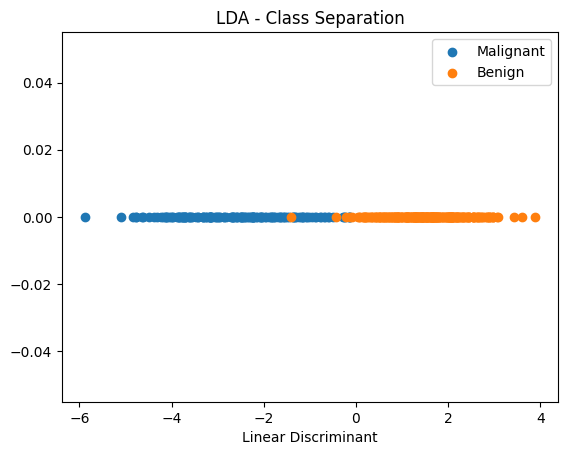

In [ ]:
plt.figure()

plt.scatter(
    X_train_lda[y_train == 0],
    np.zeros_like(X_train_lda[y_train == 0]),
    label="Malignant"
)

plt.scatter(
    X_train_lda[y_train == 1],
    np.zeros_like(X_train_lda[y_train == 1]),
    label="Benign"
)

plt.xlabel("Linear Discriminant")
plt.title("LDA - Class Separation")
plt.legend()
plt.show()